**Bayesian Network Interactive Calculator**

**Artificial Intelligence – Bonus Assignment**

Student: Gal Argov Sofer

This application demonstrates Bayesian Network inference using the Enumeration Algorithm.

**Features:**
*   Interactive Bayesian Network
*   Evidence selection
*   Query selection
*   Exact Enumeration
*   Intermediate calculations
*   Automatic normalization
*   Complexity analysis

**How to Run**
1.   Run all notebook cells.
2.   The Bayesian Network will be displayed.
3.   Select:
*   Query Variable
*   Evidence
4.   Click Calculate.
5.   The application displays:
*   Posterior probability
*   Enumeration steps
*   Joint probabilities
*   Normalization
*   Complexity analysis

**Requirements**
*   Python 3

Libraries:
*   numpy
*   pandas
*   networkx
*   matplotlib
*   ipywidgets

In [7]:
# ==========================================
# Imports
# ==========================================

import itertools

import numpy as np
import pandas as pd

import networkx as nx
import matplotlib.pyplot as plt

from ipywidgets import (
    Dropdown,
    Button,
    VBox,
    HBox,
    Output,
    HTML
)

from IPython.display import display, Markdown, clear_output

In [8]:
# ==========================================
# Bayesian Network Definition
# ==========================================

# Variables in the network
VARIABLES = [
    "Cloudy",
    "Sprinkler",
    "Rain",
    "WetGrass"
]

# Parent list
PARENTS = {
    "Cloudy": [],
    "Sprinkler": ["Cloudy"],
    "Rain": ["Cloudy"],
    "WetGrass": ["Sprinkler", "Rain"]
}

# --------------------------------------------------
# Conditional Probability Tables
# Every value stores:
# P(Node=True | Parents)
# False probability is calculated automatically.
# --------------------------------------------------

CPT = {
    "Cloudy": {
        (): 0.5
    },
    "Sprinkler": {
        (True,): 0.10,
        (False,): 0.50
    },
    "Rain": {
        (True,): 0.80,
        (False,): 0.20
    },
    "WetGrass": {
        (True, True): 0.99,
        (True, False): 0.90,
        (False, True): 0.90,
        (False, False): 0.00
    }
}

In [9]:
# ==========================================
# Helper Functions
# ==========================================

def get_probability(variable, value, assignment):
    """
    Returns
    P(variable=value | parents)
    Parameters
    ----------
    variable : str
    value : bool
    assignment : dict
        Current variable assignments.
    """
    parents = PARENTS[variable]
    parent_values = tuple(
        assignment[parent]
        for parent in parents
    )
    p_true = CPT[variable][parent_values]
    if value:
        return p_true
    return 1 - p_true

# ------------------------------------------------------


def consistent(assignment, evidence):
    """
    Checks whether assignment agrees
    with the selected evidence.
    """
    for variable, value in evidence.items():
        if assignment[variable] != value:
            return False
    return True

# ------------------------------------------------------


def all_assignments():
    """
    Generates all possible worlds.
    4 variables
    →
    16 assignments
    """
    for values in itertools.product(
        [True, False],
        repeat=len(VARIABLES)
    ):
        yield dict(
            zip(VARIABLES, values)
        )

# ------------------------------------------------------

def joint_probability(assignment):
    """
    Computes
    P(Cloudy,
      Sprinkler,
      Rain,
      WetGrass)
    using the Bayesian Network.
    """
    probability = 1.0
    for variable in VARIABLES:
        probability *= get_probability(
            variable,
            assignment[variable],
            assignment
        )
    return probability

# ------------------------------------------------------


def normalize(probabilities):
    """
    Normalizes a dictionary
    so values sum to 1.
    """
    total = sum(probabilities.values())
    return {
        key: value / total
        for key, value in probabilities.items()
    }

In [10]:
# ==========================================
# Enumeration Algorithm
# ==========================================

import time
def enumeration_ask(query_variable, evidence):
    """
    Computes
        P(Query | Evidence)
    using Enumeration.
    Returns:
        probabilities
        steps
    """
    start_time = time.perf_counter()
    steps = []
    steps.append("=" * 70)
    steps.append("BAYESIAN NETWORK - ENUMERATION ALGORITHM")
    steps.append("=" * 70)
    steps.append("")

    # ----------------------------------------------------
    # Query
    # ----------------------------------------------------
    steps.append(f"Query Variable : {query_variable}")
    steps.append("")

    # ----------------------------------------------------
    # Evidence
    # ----------------------------------------------------
    steps.append("Evidence")
    if len(evidence) == 0:
        steps.append("  None")
    else:
        for var, value in evidence.items():
            color = "🔵" if value else "🔴"
            steps.append(
                f"  {var:<12} = {color} {value}"
            )
    steps.append("")

    # ----------------------------------------------------
    # Hidden variables
    # ----------------------------------------------------
    hidden = [
        v
        for v in VARIABLES
        if v != query_variable and v not in evidence
    ]
    steps.append(f"Hidden Variables ({len(hidden)})")
    if len(hidden):
        for h in hidden:
            steps.append(f"   • {h}")
        steps.append("")
        steps.append(
            f"Assignments to evaluate = 2^{len(hidden)} = {2**len(hidden)}"
        )
    else:
        steps.append("None")
    steps.append("")
    steps.append("=" * 70)
    result = {}

    # ====================================================
    # Evaluate Query=True and Query=False
    # ====================================================
    for query_value in [True, False]:
        color = "🔵" if query_value else "🔴"
        steps.append("")
        steps.append(
            f"{color} Evaluating {query_variable} = {query_value}"
        )
        steps.append("-" * 70)
        total = 0.0
        assignment_number = 1
        for assignment in all_assignments():
            if not consistent(assignment, evidence):
                continue
            if assignment[query_variable] != query_value:
                continue
            jp = joint_probability(assignment)
            total += jp
            steps.append(
                f"\nAssignment {assignment_number}"
            )
            steps.append(
                str(assignment)
            )

            # ----------------------------------------
            # Detailed calculation
            # ----------------------------------------
            for variable in VARIABLES:
                parents = PARENTS[variable]
                if len(parents) == 0:
                    txt = (
                        f"P({variable}={assignment[variable]})"
                    )
                else:
                    parent_text = ", ".join(
                        f"{p}={assignment[p]}"
                        for p in parents
                    )
                    txt = (
                        f"P({variable}={assignment[variable]} | {parent_text})"
                    )
                probability = get_probability(
                    variable,
                    assignment[variable],
                    assignment
                )
                steps.append(
                    f"   {txt:<55} = {probability:.6f}"
                )
            steps.append(
                f"Joint Probability = {jp:.6f}"
            )
            assignment_number += 1
        steps.append("")
        steps.append(
            f"Unnormalized Sum = {total:.6f}"
        )
        result[query_value] = total

    # ====================================================
    # Normalization
    # ====================================================
    normalized = normalize(result)
    steps.append("")
    steps.append("=" * 70)
    steps.append("NORMALIZATION")
    steps.append("=" * 70)
    total_before = sum(result.values())
    steps.append(
        f"Total = {total_before:.6f}"
    )
    steps.append("")
    for value in [True, False]:
        color = "🔵" if value else "🔴"
        steps.append(
            f"{color} {query_variable}={value:<5}"
            f" -> {normalized[value]:.6f}"
        )

    # ====================================================
    # Complexity
    # ====================================================
    elapsed = time.perf_counter() - start_time
    steps.append("")
    steps.append("=" * 70)
    steps.append("COMPLEXITY")
    steps.append("=" * 70)
    steps.append(
        f"Hidden Variables : {len(hidden)}"
    )
    steps.append(
        f"Assignments      : {2**len(hidden)}"
    )
    steps.append(
        "Time Complexity  : O(2^H)"
    )
    steps.append(
        f"Execution Time   : {elapsed:.6f} sec"
    )
    return normalized, steps

In [12]:
# ==========================================
# Calculate Function
# ==========================================

def calculate_probability(query_variable, evidence):
    """
    Main calculation function.

    Parameters
    ----------
    query_variable : str

    evidence : dict
        Example:
        {
            "Cloudy": True,
            "WetGrass": False
        }

    Returns
    -------
    result : dict
        Posterior probabilities

    steps : list
        Explanation for display
    """

    # Prevent illegal query
    if query_variable in evidence:
        raise ValueError(
            "Query variable cannot also be evidence."
        )

    probabilities, steps = enumeration_ask(
        query_variable=query_variable,
        evidence=evidence
    )

    return probabilities, steps

In [13]:
# ==========================================
# Draw Network
# ==========================================

def draw_network():
    """
    Draws the Bayesian Network.
    """

    G = nx.DiGraph()

    # Nodes
    for node in VARIABLES:
        G.add_node(node)

    # Edges
    for child, parents in PARENTS.items():
        for parent in parents:
            G.add_edge(parent, child)

    # Fixed layout
    pos = {
        "Cloudy": (0, 2),
        "Sprinkler": (-1, 1),
        "Rain": (1, 1),
        "WetGrass": (0, 0)
    }

    plt.figure(figsize=(8,6))

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=3200,
        node_color="lightblue"
    )

    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowsize=25,
        width=2
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=11,
        font_weight="bold"
    )

    plt.title(
        "Bayesian Network",
        fontsize=16,
        fontweight="bold"
    )

    plt.axis("off")
    plt.show()

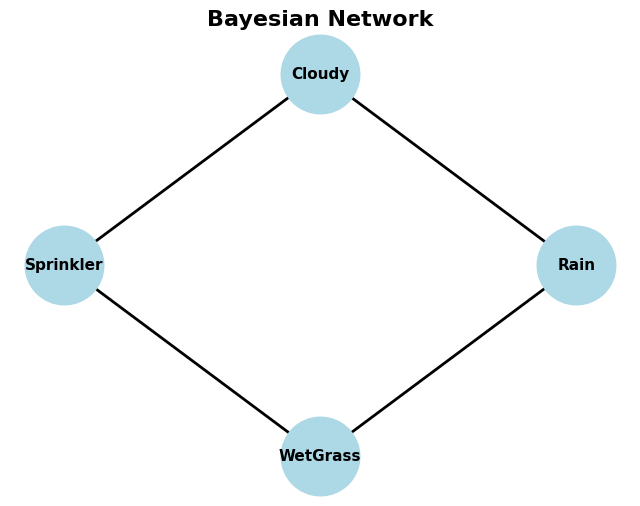

In [14]:
draw_network()

In [15]:
# ==========================================
# ipywidgets Interface
# ==========================================

# Query variable
query_dropdown = Dropdown(
    options=VARIABLES,
    value="Rain",
    description="Query:"
)

# Evidence selectors
evidence_widgets = {}

for variable in VARIABLES:

    evidence_widgets[variable] = Dropdown(
        options=[
            ("Unknown", None),
            ("True", True),
            ("False", False)
        ],
        value=None,
        description=variable
    )

# Button
calculate_button = Button(
    description="Calculate",
    button_style="success",
    icon="check"
)

# Output area
output = Output()


def on_calculate_clicked(button):

    with output:

        clear_output()

        query = query_dropdown.value

        evidence = {}

        for variable, widget in evidence_widgets.items():

            if widget.value is not None:

                evidence[variable] = widget.value

        # Validation
        if query in evidence:

            print("ERROR")
            print()
            print("The Query Variable cannot also be Evidence.")
            return

        # Draw network
        draw_network()

        print()

        probabilities, steps = calculate_probability(
            query,
            evidence
        )

        print("FINAL RESULT")
        print("=" * 70)

        for value in [True, False]:

            color = "🔵" if value else "🔴"

            print(
                f"{color} {query} = {value:<5}"
                f" : {probabilities[value]:.6f}"
            )

        print()

        for line in steps:
            print(line)


calculate_button.on_click(
    on_calculate_clicked
)

In [16]:
interface = VBox([

    HTML("<h2>Bayesian Network Calculator</h2>"),

    query_dropdown,

    HTML("<hr>"),

    HTML("<b>Evidence</b>"),

    *evidence_widgets.values(),

    calculate_button,

    output

])

Bayesian Network Interactive Calculator



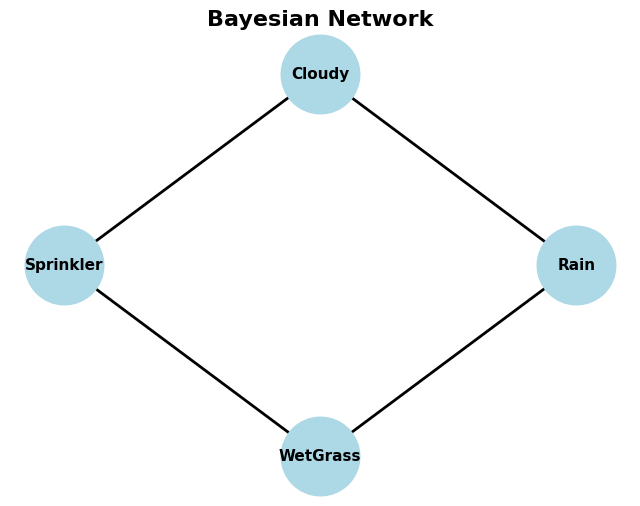


Select:
• Query Variable
• Evidence
Then press 'Calculate'



In [18]:
# ==========================================
# Run Application
# ==========================================

print("=" * 60)
print("Bayesian Network Interactive Calculator")
print("=" * 60)
print()

draw_network()

print()
print("Select:")
print("• Query Variable")
print("• Evidence")
print("Then press 'Calculate'")
print()

display(interface)